In [119]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
import scipy
import time
from scipy.interpolate import lagrange

import importlib
from ader_dg_transport.ader_dg_3D import wave_ader
import matplotlib.ticker as mticker

In [258]:
nx = ny = nz = 20
xlim = ylim = zlim = 5
poly_order = 4
c = 1.0
tend = 4.0

cfl = 0.9 * 0.34 * (2 / 3)
dt = cfl * (xlim / nx)
nsteps = (int((tend / 8) / dt) + 1) * 8
# nsteps = int(tend / dt) + 1
dt = tend / nsteps

xr = 3.5
fp = f'point_source_receiver_n{nx}_p{poly_order}_xrcv{xr}.npy'
# fp = f'point_source_receiver_n{nx}_p{poly_order}.npy'

In [259]:
importlib.reload(wave_ader)
solver = wave_ader.WaveAderDG3D(xlim, ylim, zlim, nx, ny, nz, poly_order=poly_order, c=c, dt=dt)
xs = solver.xs[:, :, :, 0]
ys = solver.ys[:, :, :, 0]
zs = solver.zs[:, :, :, 0]

x0 = 2.5
y0 = 2.5
z0 = 2.5
t0 = 0.7
sigma = 0.1149

weights = (solver.weights_3D * solver.dx * solver.dy * solver.dz / 8)[None, None, None, None]
source_mask = np.isclose(solver.xs, x0) & np.isclose(solver.ys, y0) & np.isclose(solver.zs, z0)
point_source_scale = (source_mask / weights) / (source_mask.sum() / 5)

assert source_mask.any()
print(source_mask.sum())


def g(t):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(t - t0)**2 / (2 * sigma**2))


def g_deriv(t):
    return g(t) * -(t - t0) / (sigma**2)

    
def point_source(x, y, z, t):
    out = np.zeros((x.shape[0], x.shape[1], x.shape[2], 4, x.shape[3], x.shape[4], x.shape[5], x.shape[6]))
    out[:, :, :, 3] = g(t) * point_source_scale
    return out


def h_exact(x, y, z, t):

    r = np.sqrt((x - x0)**2 + (y - y0)**2 + (z - z0)**2)

    return -g_deriv(t - (r / c)) / (4 * np.pi * r * c**2)

40


In [260]:

receiver_mask = np.isclose(xs, xr) & np.isclose(ys, y0) & np.isclose(zs, z0)
assert receiver_mask.any()

print(receiver_mask.sum())

8


In [261]:
solver.time = 0.0
solver.state[:] = 0.0

data = [0.0]
times = [0.0]
for _ in range(nsteps):
    solver.time_step(forcing_func=point_source)
    
    data.append((solver.h[receiver_mask]).mean())
    times.append(solver.time)

times = np.array(times)
data = np.array(data)

In [262]:
t_data = np.stack([times, data])
np.save(fp, np.array(t_data))

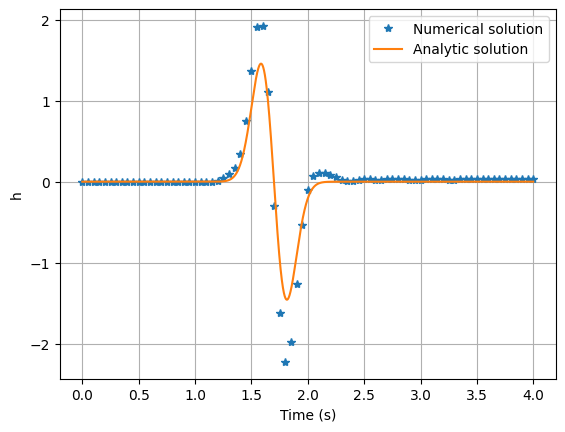

In [263]:
plt.plot(times, data, '*', label='Numerical solution')
times_ = np.linspace(0, times.max(), 10000)
plt.plot(times_, -h_exact(xr, y0, z0, times_), '-', label='Analytic solution')
plt.ylabel('h')
plt.xlabel('Time (s)')
plt.legend()
plt.grid()
# plt.savefig('point_source_receiver.png')

In [270]:
xr = 4.5

In [275]:
ns = np.array([10, 15, 25])
errors = []
for n in ns:

    t_data = np.load(f'point_source_receiver_n{n}_p{poly_order}_xrcv{xr}.npy')

    print(np.isclose(t_data[0], 3).any())

    idx = np.where(np.isclose(t_data[0], 3))[0][0]
    
    error = abs(-h_exact(xr, y0, z0, t_data[0]) - t_data[1])[idx] #.max()
    # plt.plot(t_data[0], t_data[1])
    errors.append(error)

error = np.array(errors)

True
True
True


<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/w_/6nw19zzn49v8p8ws3d1gm1kdj8tqh5/T/ipykernel_68848/982089780.py:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.xlabel('Element size $\Delta x$')


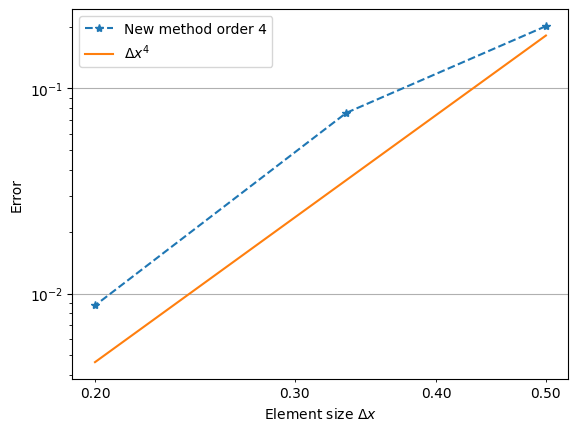

In [288]:
# plt.title('Maximum error at receiver for fourth order method')
plt.loglog(xlim / ns, error, '--*', label='New method order 4')
plt.loglog(xlim / ns, error[0] * 0.9 * (ns / ns[0])**(-4), label='$\\Delta x^{4}$')
plt.ylabel("Error")
plt.xlabel('Element size $\Delta x$')

plt.minorticks_on()
plt.gca().yaxis.set_minor_formatter(mticker.LogFormatter())
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.gca().xaxis.set_minor_formatter(mticker.ScalarFormatter())
plt.legend()
plt.grid()
plt.savefig('point_source_convergence.png')

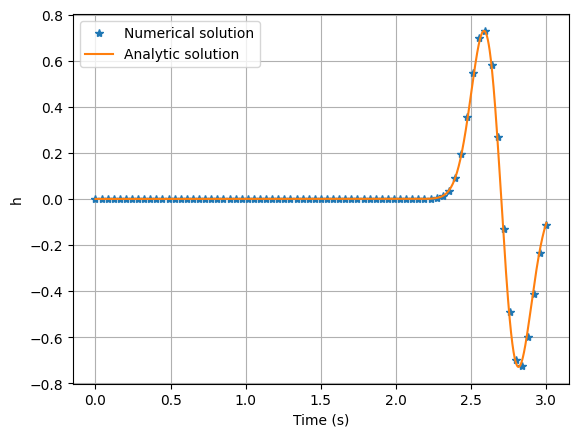

In [289]:
t_data = np.load(f'point_source_receiver_n{n}_p{poly_order}_xrcv{xr}.npy')

plt.plot(t_data[0], t_data[1], '*', label='Numerical solution')
time_ = np.linspace(0, t_data[0].max(), 5000)
plt.plot(time_, -h_exact(xr, y0, z0, time_), label='Analytic solution')
plt.ylabel('h')
plt.xlabel('Time (s)')
plt.legend()
plt.grid()
plt.savefig('point_source_receiver.png')

In [6]:
np.save(fp, t_data)

In [26]:
fp

'point_source_receiver_n10_p4.npy'

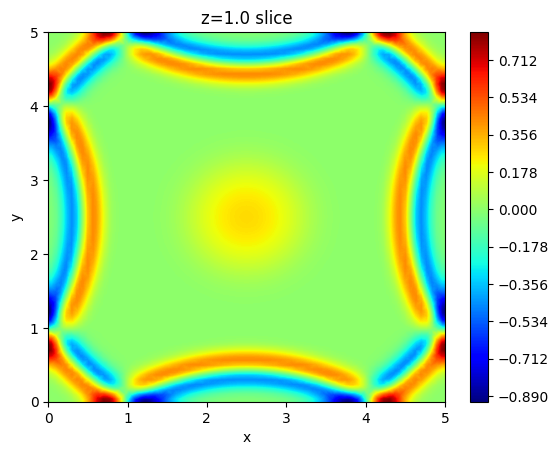

In [128]:
plt.title(f'z={zs[:, :, idx, :, :, 0].min()} slice')
plt.tricontourf(xs[:, :, idx, :, :, 0].ravel(), ys[:, :, idx, :, :, 0].ravel(), solver.h[:, :, idx, :, :, 0].ravel(), levels=1000, cmap='jet')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()

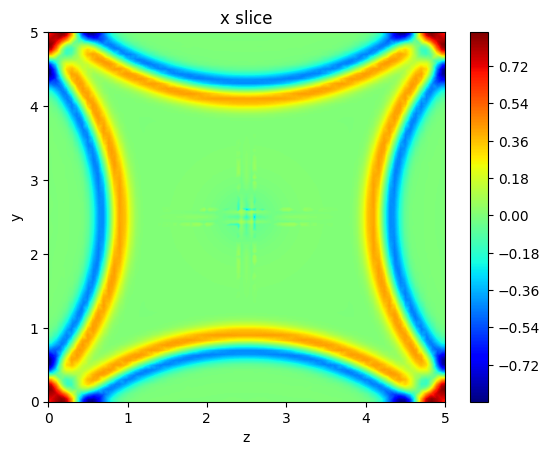

In [129]:
idx = int(nx / 2)
plt.title('x slice')
plt.tricontourf(zs[idx, :, :, 0].ravel(), ys[idx, :, :, 0].ravel(), solver.h[idx, :, :, 0].ravel(), levels=1000, cmap='jet')
plt.xlabel('z')
plt.ylabel('y')
plt.colorbar()

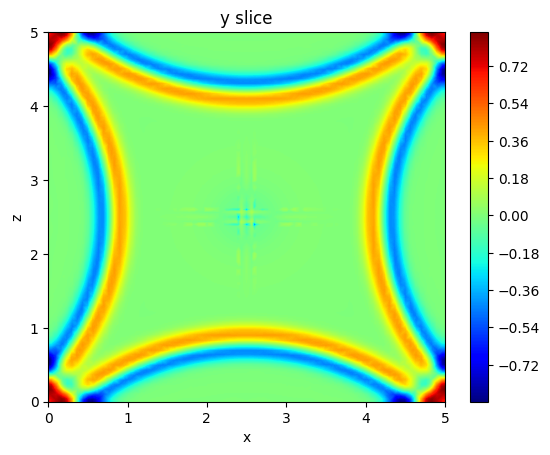

In [130]:
plt.title('y slice')
plt.tricontourf(xs[:, idx, :, :, 0].ravel(), zs[:, idx, :, :, 0].ravel(), solver.h[:, idx, :, :, 0].ravel(), levels=1000, cmap='jet')
plt.xlabel('x')
plt.ylabel('z')
plt.colorbar()